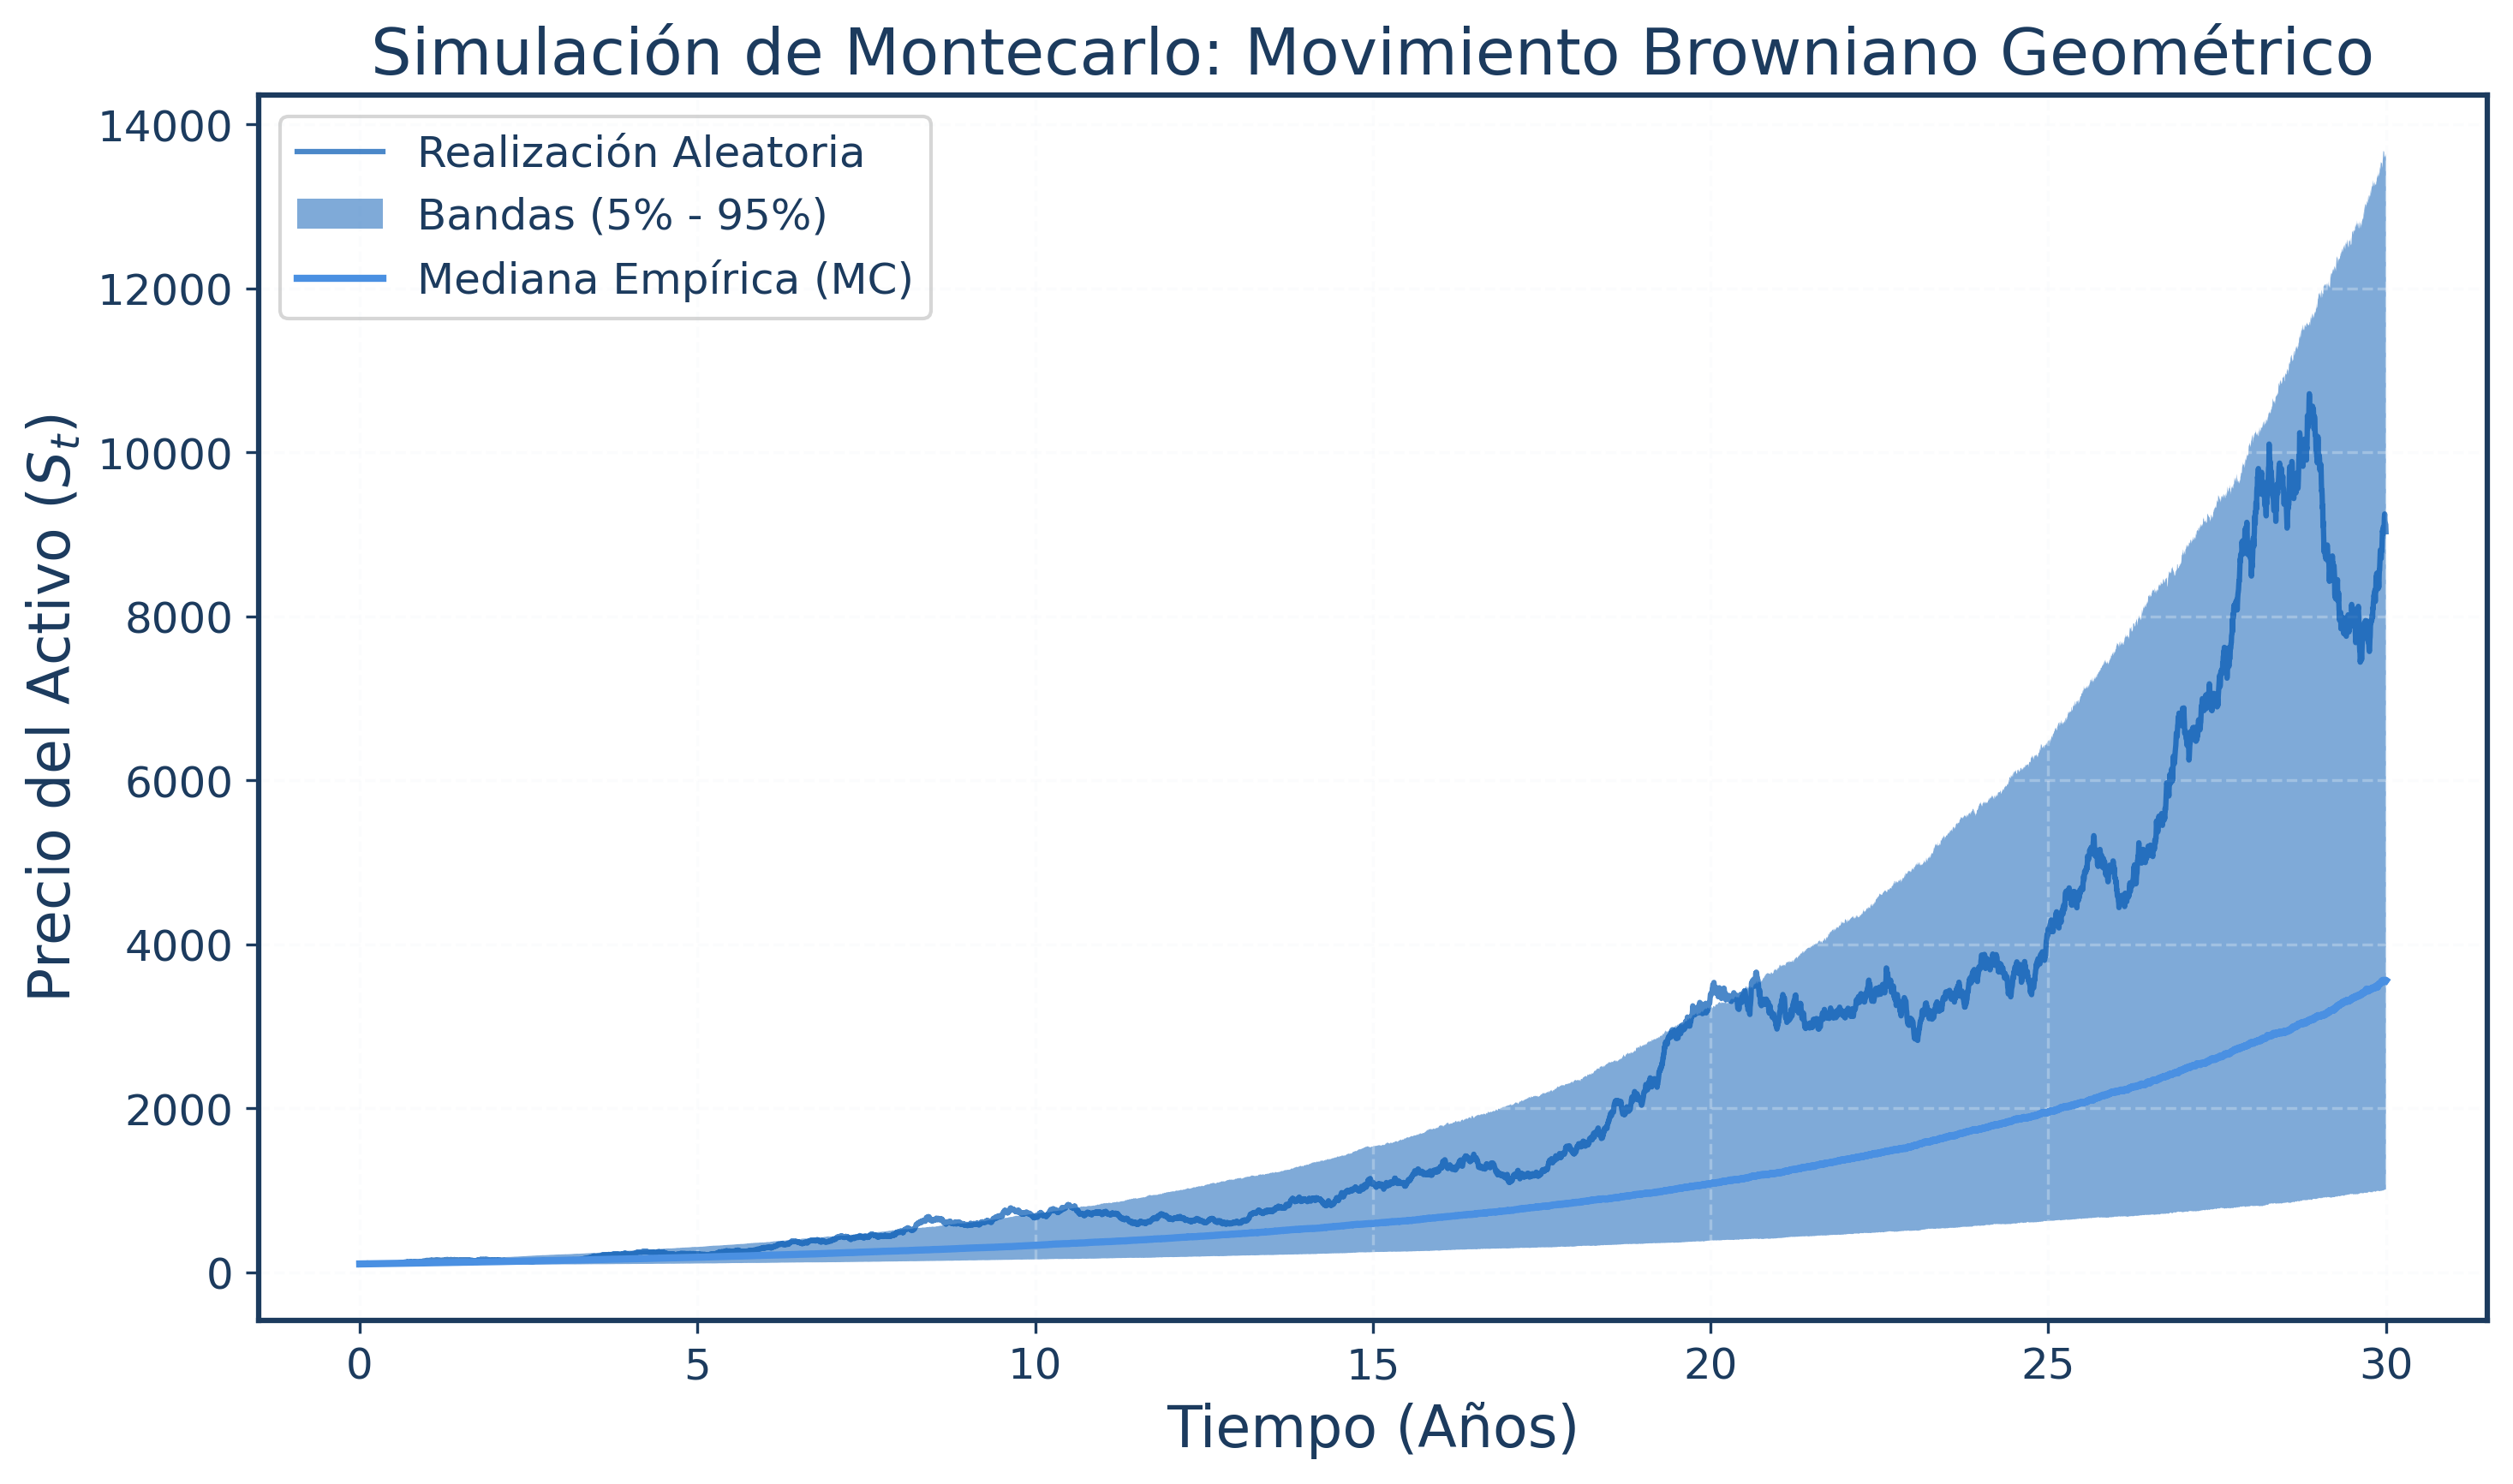

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from Core.Tools.figure_style import set_figure_style

# 1. Definición de Parámetros
S0 = 100          # Precio inicial del activo
mu = 0.13         # Drift (retorno esperado anual)
sigma = 0.147      # Volatilidad anualizada (25%)
T = 30.0           # Horizonte de tiempo (1 año)
N_steps = int(252*T)     # Número de pasos de tiempo (días de trading)
N_sims = 5000     # Número de trayectorias de Montecarlo

dt = T / N_steps
t = np.linspace(0, T, N_steps)

# 2. Generación del Movimiento Browniano (W_t)
# Extraemos variables normales estándar y hacemos una suma acumulativa
W = np.random.standard_normal(size=(N_steps, N_sims))
W = np.cumsum(W, axis=0) * np.sqrt(dt)

# 3. Cálculo de la Simulación usando la Ecuación del GBM
drift = (mu - 0.5 * sigma**2) * t[:, np.newaxis]
diffusion = sigma * W
S = S0 * np.exp(drift + diffusion)

# 4. Cálculos Estadísticos (Montecarlo)
mediana_empirica = np.median(S, axis=1)
std_empirica = np.std(S, axis=1) # Desviación estándar empírica en cada t
banda_sup = np.percentile(S, 95, axis=1) # Banda superior al 95%
banda_inf = np.percentile(S, 5, axis=1)  # Banda inferior al 5%

# 5. Solución Analítica
# OJO: La mediana teórica incluye el arrastre de volatilidad (volatility drag)
mediana_teorica = S0 * np.exp((mu - 0.5 * sigma**2) * t)

# 6. Visualización de los Resultados
plt.figure(figsize=(10, 6))
set_figure_style()
# Graficamos la realización aleatoria (solo la primera columna)
plt.plot(t, S[:, 0], alpha=0.7, label='Realización Aleatoria', linewidth=1.5)

# Graficamos las bandas de confianza de la simulación
plt.fill_between(t, banda_inf, banda_sup, alpha=0.5, label='Bandas (5% - 95%)')

# Graficamos la mediana calculada mediante Montecarlo
plt.plot(t, mediana_empirica, label='Mediana Empírica (MC)', linewidth=2)


# Detalles estéticos del gráfico
plt.title('Simulación de Montecarlo: Movimiento Browniano Geométrico')
plt.xlabel('Tiempo (Años)')
plt.ylabel('Precio del Activo ($S_t$)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Mostrar o guardar el gráfico
# plt.show()
plt.savefig('gbm_montecarlo.png')